# 03. Feature Engineering

> Poprzedni notebook: [02_data_cleaning_eda.ipynb](02_data_cleaning_eda.ipynb)

## Cel:
Przygotowanie dwóch niezależnych reprezentacji danych dla dwóch architektur modeli:

| Model | Reprezentacja wejścia | Opis |
|-------|----------------------|------|
| **MLP** | Wektor cech (tabular) | 17 deskryptorów Lipińskiego + 2048 bitów ECFP4 = 2065 cech |
| **GNN** | Graf molekularny | Atomy = wierzchołki, wiązania = krawędzie, z cechami |

## Plan działania:
1. **Wczytanie danych** - CSV + macierz fingerprints z notebook 02
2. **Scaffold Split** - podział train/val/test oparty na szkieletach Bemis-Murcko
3. **Przygotowanie cech MLP** - skalowanie, usunięcie stałych bitów, zapis
4. **Przygotowanie grafów GNN** - konwersja SMILES → graf atomów/wiązań, zapis
5. **Podsumowanie** - opis artefaktów gotowych do treningu

---

### Dlaczego Scaffold Split zamiast losowego podziału?
Losowy split może spowodować, że bardzo podobne molekuły (ten sam szkielet, inna podstawka) trafią jednocześnie do zbioru treningowego i testowego. Model "uczyłby się" przewidywać aktywność dla cząsteczek niemal identycznych z treningowymi — co daje zawyżone metryki i słabą generalizację na naprawdę nowe szkielety.

**Scaffold split** dzieli molekuły tak, że **różne szkielety Bemis-Murcko** trafiają do różnych zbiorów — co daje bardziej realistyczną ocenę zdolności do generalizacji.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import json
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator

import torch
from torch_geometric.data import Data, InMemoryDataset

print("Biblioteki podstawowe załadowane pomyślnie.")

Biblioteki podstawowe załadowane pomyślnie.


## 1. Konfiguracja i Wczytanie Danych

In [2]:
BASE_DIR = Path(r'<ŚCIEŻKA_DO_FOLDERU>')  # Zmień na swoją ścieżkę

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FEATURES_DIR  = BASE_DIR / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Pliki wejściowe (wyjście z notebook 02)
CSV_FILE = PROCESSED_DIR / "bioactivity_cleaned.csv"
FP_FILE  = PROCESSED_DIR / "morgan_fp_matrix.npy"

# Parametry podziału
VAL_FRAC  = 0.10   # 10% walidacja
TEST_FRAC = 0.10   # 10% test
RANDOM_SEED = 42

# Parametry Morgan FP (muszą być spójne z notebook 02)
MORGAN_RADIUS = 2
MORGAN_BITS   = 2048

print(f"Katalog cech: {FEATURES_DIR}")
print(f"Podział: {int((1-VAL_FRAC-TEST_FRAC)*100)}% train / {int(VAL_FRAC*100)}% val / {int(TEST_FRAC*100)}% test")

Katalog cech: C:\Users\LUMA\Documents\Projects\Personal\Chembl\data\features
Podział: 80% train / 10% val / 10% test


In [3]:
# Wczytaj oczyszczony dataset
df = pd.read_csv(CSV_FILE)
fp_matrix = np.load(FP_FILE)

print(f"Wczytano: {CSV_FILE.name}")
print(f"  Wymiary DataFrame: {df.shape}")
print(f"  Kolumny: {list(df.columns)}")
print(f"\nWczytano: {FP_FILE.name}")
print(f"  Kształt macierzy fingerprints: {fp_matrix.shape}")

assert len(df) == fp_matrix.shape[0], (
    f"BŁĄD: Liczba wierszy w CSV ({len(df)}) != liczba wierszy w fp_matrix ({fp_matrix.shape[0]}).\n"
    "Upewnij się, że pliki pochodzą z tego samego uruchomienia notebook 02."
)
print(f"\nSpójność plików: OK ({len(df):,} rekordów)")
print(f"\nZmienna docelowa (pActivity):")
print(f"  Min:    {df['pActivity'].min():.3f}")
print(f"  Max:    {df['pActivity'].max():.3f}")
print(f"  Średnia: {df['pActivity'].mean():.3f}")
print(f"  Odch. std: {df['pActivity'].std():.3f}")

Wczytano: bioactivity_cleaned.csv
  Wymiary DataFrame: (26194, 35)
  Kolumny: ['activity_id', 'molregno', 'molecule_chembl_id', 'assay_id', 'assay_chembl_id', 'tid', 'target_chembl_id', 'target_name', 'target_type', 'standard_type', 'standard_value', 'standard_units', 'pchembl_value', 'assay_type', 'confidence_score', 'canonical_smiles', 'standard_inchi_key', 'pActivity', 'MolecularWeight', 'NumAtoms', 'NumHeavyAtoms', 'NumHeteroatoms', 'NumHDonors', 'NumHAcceptors', 'LogP', 'TPSA', 'NumAromaticRings', 'NumAliphaticRings', 'NumRings', 'AromaticProportion', 'NumRotatableBonds', 'NumSaturatedRings', 'FractionCSP3', 'MolMR', 'Lipinski_Violation']

Wczytano: morgan_fp_matrix.npy
  Kształt macierzy fingerprints: (26194, 2048)

Spójność plików: OK (26,194 rekordów)

Zmienna docelowa (pActivity):
  Min:    1.011
  Max:    12.000
  Średnia: 6.790
  Odch. std: 1.354


## 2. Scaffold Split (Bemis-Murcko)

Podział na zbiory train/val/test oparty na szkieletach Bemis-Murcko.
Molekuły z tym samym szkieletem trafiają do jednego zbioru — zapobiega wyciekowi informacji o podobnych strukturach.

In [4]:
def get_scaffold(smiles: str) -> str:
    """Zwraca SMILES szkieletu Bemis-Murcko lub pusty string dla niepoprawnego SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)


def scaffold_split(df: pd.DataFrame, val_frac: float, test_frac: float, seed: int):
    """
    Podział indeksów DataFrame na train/val/test metodą scaffold split.
    Małe szkielety trafiają do walidacji/testu, duże do treningu.
    """
    print("Obliczanie szkieletów Bemis-Murcko...")
    scaffolds: dict[str, list[int]] = {}
    for idx, smiles in enumerate(df['canonical_smiles']):
        s = get_scaffold(smiles)
        scaffolds.setdefault(s, []).append(idx)

    # Sortuj szkielety: najpierw te z mniejszą liczbą molekuł (trafią do val/test)
    scaffold_groups = sorted(scaffolds.values(), key=len)

    n_total = len(df)
    n_val   = int(np.floor(val_frac  * n_total))
    n_test  = int(np.floor(test_frac * n_total))

    train_idx, val_idx, test_idx = [], [], []

    rng = np.random.default_rng(seed)
    for group in scaffold_groups:
        if len(test_idx) < n_test:
            test_idx.extend(group)
        elif len(val_idx) < n_val:
            val_idx.extend(group)
        else:
            train_idx.extend(group)

    return (
        np.array(train_idx, dtype=np.int64),
        np.array(val_idx,   dtype=np.int64),
        np.array(test_idx,  dtype=np.int64),
    )


train_idx, val_idx, test_idx = scaffold_split(df, VAL_FRAC, TEST_FRAC, RANDOM_SEED)

n = len(df)
print(f"\nPodział scaffold split:")
print(f"  Train: {len(train_idx):>6,}  ({len(train_idx)/n*100:.1f}%)")
print(f"  Val:   {len(val_idx):>6,}  ({len(val_idx)/n*100:.1f}%)")
print(f"  Test:  {len(test_idx):>6,}  ({len(test_idx)/n*100:.1f}%)")
print(f"  Suma:  {len(train_idx)+len(val_idx)+len(test_idx):>6,}")

# Zapisz indeksy — będą wspólne dla MLP i GNN
np.save(FEATURES_DIR / "split_train_idx.npy", train_idx)
np.save(FEATURES_DIR / "split_val_idx.npy",   val_idx)
np.save(FEATURES_DIR / "split_test_idx.npy",  test_idx)
print("\nIndeksy podziału zapisane.")

Obliczanie szkieletów Bemis-Murcko...

Podział scaffold split:
  Train: 20,956  (80.0%)
  Val:    2,619  (10.0%)
  Test:   2,619  (10.0%)
  Suma:  26,194

Indeksy podziału zapisane.


### Weryfikacja rozkładu pActivity po podziale

Scaffold split **nie jest losowy** — sortuje szkielety według liczebności i wypycha rzadkie szkielety do val/test. Może to prowadzić do pewnego przesunięcia rozkładu wartości `pActivity` między zbiorami. Poniższy histogram pozwala szybko ocenić, czy rozkłady są wystarczająco podobne.

> **Czego szukamy?** Trzy histogramy powinny mieć zbliżony kształt (podobne centrum i rozpiętość). Jeśli zbiór testowy byłby systematycznie przesunięty w stronę wyższych lub niższych aktywności, wynik ewaluacji modelu byłby trudny do interpretacji.

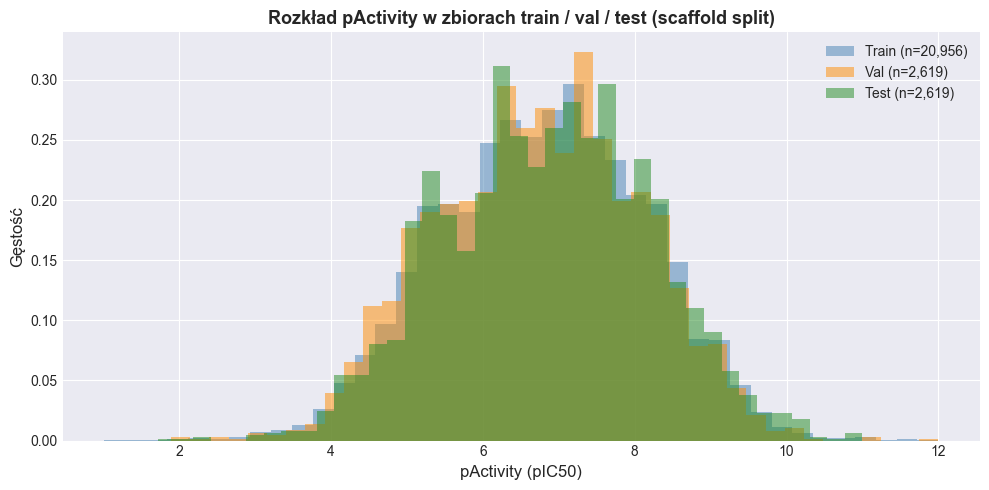

Statystyki pActivity per zbiór:
  Train  mean=6.791  std=1.355  min=1.011  max=12.000
  Val    mean=6.725  std=1.339  min=1.890  max=12.000
  Test   mean=6.849  std=1.359  min=1.720  max=11.000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Weryfikacja: rozkład pActivity w każdym zbiorze powinien być zbliżony
fig, ax = plt.subplots(figsize=(10, 5))

for idx_arr, label, color in [
    (train_idx, 'Train', 'steelblue'),
    (val_idx,   'Val',   'darkorange'),
    (test_idx,  'Test',  'forestgreen'),
]:
    values = df['pActivity'].iloc[idx_arr]
    ax.hist(values, bins=40, alpha=0.5, label=f"{label} (n={len(idx_arr):,})", color=color, density=True)

ax.set_xlabel('pActivity (pIC50)', fontsize=12)
ax.set_ylabel('Gęstość', fontsize=12)
ax.set_title('Rozkład pActivity w zbiorach train / val / test (scaffold split)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Statystyki pActivity per zbiór:")
for idx_arr, label in [(train_idx, 'Train'), (val_idx, 'Val'), (test_idx, 'Test')]:
    v = df['pActivity'].iloc[idx_arr]
    print(f"  {label:5s}  mean={v.mean():.3f}  std={v.std():.3f}  min={v.min():.3f}  max={v.max():.3f}")

## 3. Przygotowanie Cech dla MLP

### Strategia:
- **Wejście**: 17 deskryptorów Lipińskiego (skalowane) + 2048 bitów ECFP4 (binarne, bez skalowania)
- Usunięcie stałych bitów fingerprints (zero wariancji w zbiorze treningowym)
- `StandardScaler` dopasowany **tylko na zbiorze treningowym**, stosowany do val i test
- Wynik: tablice numpy `X_train`, `X_val`, `X_test` + wektor `y`

In [6]:
# Kolumny deskryptorów Lipińskiego (identyczne jak w notebook 02)
DESCRIPTOR_COLS = [
    'MolecularWeight', 'NumAtoms', 'NumHeavyAtoms', 'NumHeteroatoms',
    'NumHDonors', 'NumHAcceptors', 'LogP', 'TPSA',
    'NumAromaticRings', 'NumAliphaticRings', 'NumRings', 'AromaticProportion',
    'NumRotatableBonds', 'NumSaturatedRings', 'FractionCSP3', 'MolMR',
    'Lipinski_Violation'
]

desc_matrix = df[DESCRIPTOR_COLS].values.astype(np.float32)
y = df['pActivity'].values.astype(np.float32)

print(f"Deskryptory Lipińskiego: {desc_matrix.shape}")
print(f"Morgan fingerprints:     {fp_matrix.shape}")
print(f"Zmienna docelowa (y):    {y.shape}")

Deskryptory Lipińskiego: (26194, 17)
Morgan fingerprints:     (26194, 2048)
Zmienna docelowa (y):    (26194,)


### Pipeline przetwarzania cech MLP

Wektory cech dla MLP składają się z dwóch komponentów łączonych konkatenacją:

```
X = [deskryptory_skalowane | bity_ECFP4_przefiltrowane]
     ← 17 cech →           ← do 2048 bitów →
```

**Dlaczego skalujemy deskryptory, ale nie fingerprints?**  
Deskryptory Lipińskiego mają różne skale (np. `MolecularWeight` ~300, `NumHDonors` ~2). Bez normalizacji większe wartości numeryczne dominowałyby gradient podczas uczenia. Bity ECFP4 są binarne (0/1) — mają już wspólną skalę, skalowanie ich nie przyniosłoby korzyści, a mogłoby zniekształcić rzadkie bity.

**Dlaczego `VarianceThreshold(0.0)` na fingerprints?**  
Bity z wariancją = 0 w zbiorze treningowym mają tę samą wartość (zawsze 0 lub zawsze 1) dla każdej molekuły. Taki bit nie dostarcza modelowi żadnej informacji różnicującej — zachowywanie go to zbędny szum w przestrzeni wejściowej.

**Zasada: fit tylko na train, transform na val/test**  
Zarówno `StandardScaler` jak i `VarianceThreshold` są dopasowywane **wyłącznie na zbiorze treningowym**. Stosowanie ich do val/test nie może "widzieć" statystyk ze zbioru testowego — to zapobiega wyciekowi danych (*data leakage*).

In [7]:
# --- Krok 1: Skalowanie deskryptorów ---
# Scaler dopasowywany TYLKO na train, stosowany do val i test
desc_train = desc_matrix[train_idx]
desc_val   = desc_matrix[val_idx]
desc_test  = desc_matrix[test_idx]

scaler = StandardScaler()
desc_train_scaled = scaler.fit_transform(desc_train).astype(np.float32)
desc_val_scaled   = scaler.transform(desc_val).astype(np.float32)
desc_test_scaled  = scaler.transform(desc_test).astype(np.float32)

print("Skalowanie deskryptorów: OK (StandardScaler dopasowany na train)")

# --- Krok 2: Usunięcie stałych bitów fingerprints ---
# Bity, które są stałe w zbiorze treningowym, nie wnoszą informacji
fp_train = fp_matrix[train_idx].astype(np.float32)
fp_val   = fp_matrix[val_idx].astype(np.float32)
fp_test  = fp_matrix[test_idx].astype(np.float32)

selector = VarianceThreshold(threshold=0.0)   # usuwa bity o wariancji = 0
fp_train_sel = selector.fit_transform(fp_train).astype(np.float32)
fp_val_sel   = selector.transform(fp_val).astype(np.float32)
fp_test_sel  = selector.transform(fp_test).astype(np.float32)

removed_bits = MORGAN_BITS - fp_train_sel.shape[1]
print(f"\nFingerprints — usunięto stałe bity: {removed_bits} / {MORGAN_BITS}")
print(f"Pozostałe bity: {fp_train_sel.shape[1]}")

# --- Krok 3: Konkatenacja deskryptorów + fingerprints ---
X_train = np.concatenate([desc_train_scaled, fp_train_sel], axis=1)
X_val   = np.concatenate([desc_val_scaled,   fp_val_sel],   axis=1)
X_test  = np.concatenate([desc_test_scaled,  fp_test_sel],  axis=1)

y_train = y[train_idx]
y_val   = y[val_idx]
y_test  = y[test_idx]

print(f"\nFinalne wymiary cech MLP:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"\nŁączna liczba cech MLP: {X_train.shape[1]}")
print(f"  ({len(DESCRIPTOR_COLS)} deskryptorów + {fp_train_sel.shape[1]} bitów ECFP4)")

Skalowanie deskryptorów: OK (StandardScaler dopasowany na train)

Fingerprints — usunięto stałe bity: 0 / 2048
Pozostałe bity: 2048

Finalne wymiary cech MLP:
  X_train: (20956, 2065)
  X_val:   (2619, 2065)
  X_test:  (2619, 2065)
  y_train: (20956,)

Łączna liczba cech MLP: 2065
  (17 deskryptorów + 2048 bitów ECFP4)


In [8]:
import pickle

# Zapis macierzy cech MLP
np.save(FEATURES_DIR / "mlp_X_train.npy", X_train)
np.save(FEATURES_DIR / "mlp_X_val.npy",   X_val)
np.save(FEATURES_DIR / "mlp_X_test.npy",  X_test)
np.save(FEATURES_DIR / "mlp_y_train.npy", y_train)
np.save(FEATURES_DIR / "mlp_y_val.npy",   y_val)
np.save(FEATURES_DIR / "mlp_y_test.npy",  y_test)

# Zapis preprocessorów (potrzebne podczas inferencji dla nowych SMILES)
with open(FEATURES_DIR / "mlp_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(FEATURES_DIR / "mlp_fp_selector.pkl", "wb") as f:
    pickle.dump(selector, f)

print("Zapisano pliki MLP:")
for fname in sorted(FEATURES_DIR.glob("mlp_*")):
    size_kb = fname.stat().st_size / 1024
    print(f"  {fname.name:<30s}  {size_kb:>8.1f} KB")

Zapisano pliki MLP:
  mlp_fp_selector.pkl                 16.3 KB
  mlp_scaler.pkl                       0.8 KB
  mlp_X_test.npy                   21126.0 KB
  mlp_X_train.npy                 169039.7 KB
  mlp_X_val.npy                    21126.0 KB
  mlp_y_test.npy                      10.4 KB
  mlp_y_train.npy                     82.0 KB
  mlp_y_val.npy                       10.4 KB


## 4. Przygotowanie Grafów Molekularnych dla GNN

### Reprezentacja grafu:
- **Wierzchołek (atom)** — 9 cech:

  | Cecha | Typ | Opis |
  |-------|-----|------|
  | Atomic number | int | Liczba atomowa (C=6, N=7, O=8 ...) |
  | Degree | int | Liczba sąsiednich atomów |
  | Formal charge | int | Ładunek formalny |
  | Num Hs | int | Liczba atomów wodoru |
  | Is aromatic | bool | Czy atom aromatyczny |
  | Hybridization | one-hot (5) | SP, SP2, SP3, SP3D, SP3D2 |

- **Krawędź (wiązanie)** — 4 cechy:

  | Cecha | Typ | Opis |
  |-------|-----|------|
  | Bond type | one-hot (4) | single, double, triple, aromatic |
  | Is in ring | bool | Czy wiązanie w pierścieniu |
  | Is conjugated | bool | Czy wiązanie skoniugowane |

- **Etykieta grafu**: `y = pActivity` (pIC50)

> **Wymaganie**: `pip install torch torch_geometric`

In [10]:
from rdkit.Chem import rdchem

# Słowniki kodowania one-hot
HYBRIDIZATION_MAP = {
        rdchem.HybridizationType.SP:    0,
        rdchem.HybridizationType.SP2:   1,
        rdchem.HybridizationType.SP3:   2,
        rdchem.HybridizationType.SP3D:  3,
        rdchem.HybridizationType.SP3D2: 4,
    }
BOND_TYPE_MAP = {
    rdchem.BondType.SINGLE:    0,
    rdchem.BondType.DOUBLE:    1,
    rdchem.BondType.TRIPLE:    2,
    rdchem.BondType.AROMATIC:  3,
    }
N_HYBRIDIZATION = 5  # SP, SP2, SP3, SP3D, SP3D2
N_BOND_TYPES    = 4  # single, double, triple, aromatic

def atom_features(atom) -> list:
    """Wektor cech dla jednego atomu (9 wartości)."""
    hyb_onehot = [0] * N_HYBRIDIZATION
    hyb_idx = HYBRIDIZATION_MAP.get(atom.GetHybridization(), -1)
    if hyb_idx >= 0:
        hyb_onehot[hyb_idx] = 1

    return [
        atom.GetAtomicNum(),                          # liczba atomowa
        atom.GetDegree(),                             # stopień (liczba sąsiadów)
        atom.GetFormalCharge(),                       # ładunek formalny
        atom.GetTotalNumHs(),                         # liczba wodorów
        int(atom.GetIsAromatic()),                    # aromatyczność
    ] + hyb_onehot                                    # hybridyzacja (one-hot x5)
    # Łącznie: 5 + 5 = 10 cech na atom

def bond_features(bond) -> list:
    """Wektor cech dla jednego wiązania (6 wartości)."""
    btype_onehot = [0] * N_BOND_TYPES
    btype_idx = BOND_TYPE_MAP.get(bond.GetBondType(), -1)
    if btype_idx >= 0:
        btype_onehot[btype_idx] = 1

    return btype_onehot + [                           # typ wiązania (one-hot x4)
        int(bond.IsInRing()),                         # czy w pierścieniu
        int(bond.GetIsConjugated()),                  # czy skoniugowane
    ]
    # Łącznie: 4 + 2 = 6 cech na wiązanie

def smiles_to_graph(smiles: str, y_val: float) -> 'Data | None':
    """
    Konwertuje SMILES i wartość pIC50 na obiekt PyTorch Geometric Data.
    Zwraca None dla niepoprawnego SMILES.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Cechy wierzchołków
    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()],
        dtype=torch.float
    )  # kształt: (num_atoms, 10)

    # Indeksy krawędzi + cechy wiązań (graf nieskierowany: każde wiązanie 2×)
    edge_index_list = []
    edge_attr_list  = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index_list += [[i, j], [j, i]]   # obie strony
        edge_attr_list  += [bf, bf]

    if len(edge_index_list) == 0:
        # Molekuła jednoatomowa — dodaj pętlę własną żeby graf nie był pusty
        edge_index_list = [[0, 0]]
        edge_attr_list  = [[0] * (N_BOND_TYPES + 2)]

    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()  # (2, num_edges)
    edge_attr  = torch.tensor(edge_attr_list,  dtype=torch.float)                  # (num_edges, 6)

    y = torch.tensor([y_val], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

print("Funkcje atom_features(), bond_features(), smiles_to_graph() zdefiniowane.")
print(f"  Cechy atomu:    10 (5 skalarne + 5 hybr. one-hot)")
print(f"  Cechy wiązania:  6 (4 typ one-hot + 2 binarne)")

# Szybki test na przykładowej cząsteczce (kwas acetylosalicylowy — aspiryna)
test_data = smiles_to_graph('CC(=O)Oc1ccccc1C(=O)O', 6.5)
if test_data is not None:
    print(f"\nTest (aspiryna):")
    print(f"  x.shape:          {test_data.x.shape}  (atomy × cechy)")
    print(f"  edge_index.shape: {test_data.edge_index.shape}")
    print(f"  edge_attr.shape:  {test_data.edge_attr.shape}")
    print(f"  y:                {test_data.y}")

Funkcje atom_features(), bond_features(), smiles_to_graph() zdefiniowane.
  Cechy atomu:    10 (5 skalarne + 5 hybr. one-hot)
  Cechy wiązania:  6 (4 typ one-hot + 2 binarne)

Test (aspiryna):
  x.shape:          torch.Size([13, 10])  (atomy × cechy)
  edge_index.shape: torch.Size([2, 26])
  edge_attr.shape:  torch.Size([26, 6])
  y:                tensor([6.5000])


In [11]:
from tqdm import tqdm

print(f"Konwersja {len(df):,} SMILES → grafy molekularne...")

graph_dataset = []
invalid_gnn = 0

for idx, (smiles, pact) in enumerate(tqdm(
    zip(df['canonical_smiles'], df['pActivity']),
    total=len(df),
    desc="SMILES → Graf"
)):
    g = smiles_to_graph(smiles, float(pact))
    if g is None:
        invalid_gnn += 1
        graph_dataset.append(None)   # zachowaj wyrównanie z indeksami split
    else:
        graph_dataset.append(g)

valid_graphs = sum(1 for g in graph_dataset if g is not None)
print(f"\nGrafy wygenerowane: {valid_graphs:,} poprawnych / {invalid_gnn} błędów")

# Przykładowe statystyki
node_counts = [g.x.shape[0] for g in graph_dataset if g is not None]
edge_counts = [g.edge_index.shape[1] for g in graph_dataset if g is not None]
print(f"\nStatystyki grafów:")
print(f"  Atomy/molekułę:   min={min(node_counts)}  max={max(node_counts)}  śr.={np.mean(node_counts):.1f}")
print(f"  Krawędzie/mol.:   min={min(edge_counts)}  max={max(edge_counts)}  śr.={np.mean(edge_counts):.1f}")

Konwersja 26,194 SMILES → grafy molekularne...


SMILES → Graf: 100%|██████████| 26194/26194 [00:16<00:00, 1558.97it/s]


Grafy wygenerowane: 26,194 poprawnych / 0 błędów

Statystyki grafów:
  Atomy/molekułę:   min=7  max=369  śr.=33.2
  Krawędzie/mol.:   min=12  max=754  śr.=72.7


In [12]:

def subset_graphs(dataset, indices):
    """Zwraca listę grafów dla podanych indeksów, pomija None."""
    return [dataset[i] for i in indices if dataset[i] is not None]

graphs_train = subset_graphs(graph_dataset, train_idx)
graphs_val   = subset_graphs(graph_dataset, val_idx)
graphs_test  = subset_graphs(graph_dataset, test_idx)

print(f"Grafy po podziale scaffold split:")
print(f"  Train: {len(graphs_train):,}")
print(f"  Val:   {len(graphs_val):,}")
print(f"  Test:  {len(graphs_test):,}")

# Zapis listy grafów (pickle)
# torch.save jest zalecane dla obiektów PyTorch Geometric
torch.save(graphs_train, FEATURES_DIR / "gnn_graphs_train.pt")
torch.save(graphs_val,   FEATURES_DIR / "gnn_graphs_val.pt")
torch.save(graphs_test,  FEATURES_DIR / "gnn_graphs_test.pt")

print("\nZapisano pliki GNN:")
for fname in sorted(FEATURES_DIR.glob("gnn_*")):
    size_mb = fname.stat().st_size / (1024**2)
    print(f"  {fname.name:<30s}  {size_mb:>6.1f} MB")

Grafy po podziale scaffold split:
  Train: 20,956
  Val:   2,619
  Test:  2,619

Zapisano pliki GNN:
  gnn_graphs_test.pt                13.8 MB
  gnn_graphs_train.pt              106.1 MB
  gnn_graphs_val.pt                 13.9 MB


## 5. Podsumowanie

Ten notebook wygenerował kompletny zestaw artefaktów gotowych do treningu modeli w notebook 04.

### Co zostało zapisane?

**Wspólne dla MLP i GNN:**
- `split_train_idx.npy`, `split_val_idx.npy`, `split_test_idx.npy` — indeksy podziału scaffold split

**MLP (wektor cech):**
- `mlp_X_train/val/test.npy` — macierze cech (deskryptory + fingerprints)
- `mlp_y_train/val/test.npy` — wartości docelowe pActivity
- `mlp_scaler.pkl` — dopasowany `StandardScaler` (niezbędny przy inferencji)
- `mlp_fp_selector.pkl` — dopasowany `VarianceThreshold` (niezbędny przy inferencji)

**GNN (grafy molekularne):**
- `gnn_graphs_train/val/test.pt` — listy obiektów `torch_geometric.data.Data`

### Kluczowe decyzje projektowe

| Decyzja | Uzasadnienie |
|---------|-------------|
| Scaffold split zamiast losowego | Bardziej realistyczna ocena generalizacji na nowe szkielety chemiczne |
| `fit` tylko na train | Zapobiega wyciekowi informacji ze zbioru testowego do preprocessorów |
| One-hot dla hybrydyzacji / typu wiązania | Eliminuje fałszywą kolejność kategorii przy kodowaniu numerycznym |
| Nieskierowany graf (krawędzie ×2) | Kompatybilność ze standardowymi operatorami konwolucji grafowej |
| Zapis preprocessorów jako `.pkl` | Umożliwia odtworzenie identycznej transformacji podczas inferencji |

In [14]:
# Zapis metadanych feature engineeringu
fe_metadata = {
    "created_from": "bioactivity_cleaned.csv + morgan_fp_matrix.npy",
    "split_method": "Bemis-Murcko scaffold split",
    "split_fractions": {"train": 1 - VAL_FRAC - TEST_FRAC, "val": VAL_FRAC, "test": TEST_FRAC},
    "split_counts": {
        "train": int(len(train_idx)),
        "val":   int(len(val_idx)),
        "test":  int(len(test_idx)),
    },
    "mlp": {
        "n_descriptor_features": len(DESCRIPTOR_COLS),
        "descriptor_names": DESCRIPTOR_COLS,
        "n_fp_bits_original": MORGAN_BITS,
        "n_fp_bits_after_variance_filter": int(fp_train_sel.shape[1]),
        "n_total_features": int(X_train.shape[1]),
        "preprocessing": "StandardScaler (descriptors) + VarianceThreshold(0.0) (FP)",
        "files": [
            "mlp_X_train.npy", "mlp_X_val.npy", "mlp_X_test.npy",
            "mlp_y_train.npy", "mlp_y_val.npy", "mlp_y_test.npy",
            "mlp_scaler.pkl", "mlp_fp_selector.pkl",
        ],
    },
    "gnn": {
        "node_feature_dim": 10,
        "node_features": "atomic_num, degree, formal_charge, num_hs, is_aromatic, hybridization_onehot(5)",
        "edge_feature_dim": 6,
        "edge_features": "bond_type_onehot(4), is_in_ring, is_conjugated",
        "files": ["gnn_graphs_train.pt", "gnn_graphs_val.pt", "gnn_graphs_test.pt"],
    },
    "split_index_files": ["split_train_idx.npy", "split_val_idx.npy", "split_test_idx.npy"],
}

with open(FEATURES_DIR / "feature_engineering_metadata.json", "w") as f:
    json.dump(fe_metadata, f, indent=2)

print("=" * 60)
print("PODSUMOWANIE FEATURE ENGINEERING")
print("=" * 60)
print(f"\nKatalog wyjściowy: {FEATURES_DIR}")
print(f"\n[Podział danych]")
print(f"  Metoda:  Scaffold split (Bemis-Murcko)")
print(f"  Train:   {len(train_idx):,}")
print(f"  Val:     {len(val_idx):,}")
print(f"  Test:    {len(test_idx):,}")
print(f"\n[MLP — wektor cech]")
print(f"  Deskryptory Lipińskiego (skalowane): {len(DESCRIPTOR_COLS)}")
print(f"  Bity ECFP4 po filtracji wariancji:   {fp_train_sel.shape[1]}")
print(f"  ŁĄCZNIE cech:                        {X_train.shape[1]}")
print(f"\n[GNN — grafy molekularne]")
print(f"  Cechy atomu:    10  (5 skalarne + 5 hybr. one-hot)")
print(f"  Cechy wiązania:  6  (4 typ one-hot + 2 binarne)")
print(f"  Grafy train:    {len(graphs_train):,}")
print(f"  Grafy val:      {len(graphs_val):,}")
print(f"  Grafy test:     {len(graphs_test):,}")

print(f"\n> Następny notebook: 04_model_training.ipynb")

PODSUMOWANIE FEATURE ENGINEERING

Katalog wyjściowy: C:\Users\LUMA\Documents\Projects\Personal\Chembl\data\features

[Podział danych]
  Metoda:  Scaffold split (Bemis-Murcko)
  Train:   20,956
  Val:     2,619
  Test:    2,619

[MLP — wektor cech]
  Deskryptory Lipińskiego (skalowane): 17
  Bity ECFP4 po filtracji wariancji:   2048
  ŁĄCZNIE cech:                        2065

[GNN — grafy molekularne]
  Cechy atomu:    10  (5 skalarne + 5 hybr. one-hot)
  Cechy wiązania:  6  (4 typ one-hot + 2 binarne)
  Grafy train:    20,956
  Grafy val:      2,619
  Grafy test:     2,619

> Następny notebook: 04_model_training.ipynb
